## EDA (Exploratory Data Analysis)


## Objectives

* Explore the dataset to identify patterns, trends, and relationships between variables, particularly those influencing student dropout.

## Inputs

* Cleaned dataset: clean_student_dropout_dataset.csv
* Features: demographic, academic, and financial variables
* Target variable: Dropout

## Outputs

* Summary statistics (mean, median, standard deviation)
* Distribution plots (age, grades, dropout)
* Correlation matrix
* Key insights supporting hypotheses

## Additional Comments

* EDA helps understand data structure before modelling, identify important variables influencing dropout and support hypothesis testing and feature selection.



---

## Core Statistical Concepts

### Descriptive Statistics

Descriptive statistics are used to summarise and describe sections of a dataset. In this project, descriptive statistics are used to analyse student demographics, academic performance, behaviour, and dropout patterns.

### Mean (μ)

What is the mean?

The mean is the average of a dataset and is calculated by summing all values and dividing by the number of observations. The mean can be affected by outliers.

In the context of the dataset:

Variables such as GPA, CGPA, Study_Hours_per_Day, and Attendance_Rate can be analysed using the mean to understand typical student performance and behaviour.

### Median

What is the median?

The median is the middle value when data is ordered. It is less affected by extreme values.

In the context of the dataset:

If a small number of students have extremely high or low GPAs or study hours, the median may better represent the typical student.

### Variance (σ²) and Standard Deviation (σ)

What are variance and standard deviation?

They measure how spread out values are around the mean.

In the context of the dataset:

A high standard deviation in variables such as Attendance_Rate or Stress_Index indicates large differences between students.

### Percentiles and Quartiles

What are percentiles and quartiles?

They divide data into equal parts. Quartiles split the data into four sections.

IQR = Q3 − Q1

In the context of the dataset:

These can be used to understand distributions of GPA, Study_Hours_per_Day, or Attendance_Rate, showing where most students fall.

### Probability & Distributions

Probability measures how likely an event is, ranging from 0 to 1.

### Probability Basics

P(A or B) = P(A) + P(B) − P(A and B)  
P(A and B) = P(A) × P(B|A)

In the context of the dataset:

If a proportion of students drop out, this represents the probability of dropout when selecting a student at random.

### Normal Distribution (Gaussian)

A normal distribution is symmetrical and bell-shaped.

In the context of the dataset:

Variables such as GPA or Attendance_Rate may follow a roughly normal distribution, while others such as Assignment_Delay_Days or Stress_Index may be skewed.

### Skewness

Right-skewed: tail on the right  
Left-skewed: tail on the left  

In the context of the dataset:

Variables such as Assignment_Delay_Days or Travel_Time_Minutes may be right-skewed if most students have low values and a few have very high values.

### Central Limit Theorem (CLT)

The Central Limit Theorem states that as the sample size increases, the distribution of the sample mean approaches a normal distribution.

In the context of the dataset:

With 10,000 students, statistical analysis can be applied reliably even if some variables are not perfectly normally distributed.

### Hypothesis Testing Framework

Hypothesis testing is used to determine whether relationships in the data are statistically significant.

### Null Hypothesis (H₀)

The null hypothesis represents no relationship or difference.

In the context of the dataset:

There is no relationship between academic performance (e.g. GPA) and dropout.

### Alternative Hypothesis (H₁)

The alternative hypothesis represents a relationship or difference.

In the context of the dataset:

Lower academic performance is associated with a higher likelihood of dropout.

### P-Value

The p-value measures the probability of observing the results if the null hypothesis is true.

If p < 0.05, the null hypothesis is rejected.  
If p ≥ 0.05, the null hypothesis is not rejected.

### Significance Level (α)

The significance level is typically set at 0.05.

### Confidence Intervals

A confidence interval provides a range where the true value is likely to lie.

### Types of Statistical Tests Used in This Analysis

### Pearson Correlation

Pearson correlation measures the strength and direction of a linear relationship between two numerical variables.

In the context of the dataset:

It is used to analyse relationships between variables such as GPA, Attendance_Rate, Study_Hours_per_Day, and Dropout.

### T-Test

A t-test compares the means of two independent groups.

In the context of the dataset:

It is used to compare the mean GPA or Attendance_Rate between students who dropped out and those who did not.

### ANOVA

ANOVA compares the means of three or more groups.

In the context of the dataset:

It is used to compare variables such as GPA or Stress_Index across different departments or levels of parental education.

---

## Exploratory Analysis

In [1]:
import os

In [4]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style("whitegrid")

In [6]:
# load the clean dataset
df = pd.read_csv("../Dataset/Processed/clean_student_dropout_dataset.csv")  

## Initial Data exploration
* Previewing the data about student dropouts to understand the structure, size and contents before analysis.

In [7]:
# display the first few rows of the dataset using head()
df.head()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,0,25000.0,1,3.36,86.1,2,20.4,1,0,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,0,25000.0,1,4.30,68.0,2,44.0,0,0,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,0,40183.0,1,4.40,70.9,0,48.9,1,0,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,5,20.5,1,25319.0,1,4.19,75.7,1,23.0,0,0,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0
4,7,24.5,0,25000.0,1,3.00,78.2,1,37.4,1,1,7.3,0.64,0.33,0.44,Year 4,CS,Bachelor,0


The .head() shows the first 5 rows, which is used for a quick check of the structure and format of the data.

In [8]:
# display the last few rows of the dataset
df.tail()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
9015,9996,23.9,1,42286.0,0,4.62,92.0,0,10.0,1,1,5.5,1.60,0.99,0.97,Year 2,Arts,Bachelor,0
9016,9997,17.0,1,61103.0,1,2.87,75.2,3,32.4,0,1,6.7,3.09,3.09,3.09,Year 1,Business,Master,1
9017,9998,19.4,0,25000.0,1,4.73,74.9,4,25.4,0,0,3.5,3.45,3.37,3.43,Year 4,Business,Bachelor,0
9018,9999,22.1,1,40302.0,1,5.85,74.2,1,5.0,0,1,6.2,3.35,3.34,3.34,Year 1,CS,High School,0
9019,10000,22.4,1,76796.0,1,4.95,83.7,1,15.5,1,0,7.9,2.17,2.20,2.20,Year 1,Arts,Master,0


The .tail() shows the last 5 rows of the dataset, this is also a good indication to check that the data is there and correct.

In [11]:
# check the shape of the dataset
print("Shape of the dataset:", df.shape)

Shape of the dataset: (9020, 19)


The shape of the dataset shows how many rows and columns the dataset has, there are 9,020 rows and 19 columns

In [39]:
# show the information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9020 entries, 0 to 9019
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             9020 non-null   int64  
 1   Age                    9020 non-null   float64
 2   Gender                 9020 non-null   int64  
 3   Family_Income          9020 non-null   float64
 4   Internet_Access        9020 non-null   int64  
 5   Study_Hours_per_Day    9020 non-null   float64
 6   Attendance_Rate        9020 non-null   float64
 7   Assignment_Delay_Days  9020 non-null   int64  
 8   Travel_Time_Minutes    9020 non-null   float64
 9   Part_Time_Job          9020 non-null   int64  
 10  Scholarship            9020 non-null   int64  
 11  Stress_Index           9020 non-null   float64
 12  GPA                    9020 non-null   float64
 13  Semester_GPA           9020 non-null   float64
 14  CGPA                   9020 non-null   float64
 15  Seme

The .info() displays the information about the dataset, name of the columns, non-null count and the data type. The non-null values confirms the data is clean.

In [12]:
# describe the dataset to get summary statistics
df.describe()

,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000,9020.000000
mean,4987.913193,21.025754,0.499778,38443.460532,0.877051,4.016183,81.971563,1.800776,30.153847,0.402993,0.351774,5.504202,2.307942,2.300035,2.298906,0.234812
std,2888.368995,2.141807,0.500028,20618.661013,0.328397,1.294489,7.988880,1.349337,11.960170,0.490527,0.477550,1.767680,1.061883,1.074079,1.072379,0.423904
min,1.000000,17.000000,0.000000,25000.000000,0.000000,0.500000,50.000000,0.000000,5.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2479.750000,19.500000,0.000000,25000.000000,1.000000,3.160000,76.600000,1.000000,21.800000,0.000000,0.000000,4.300000,1.550000,1.520000,1.520000,0.000000
50%,4969.000000,21.000000,0.000000,29764.000000,1.000000,4.010000,82.000000,2.000000,30.100000,0.000000,0.000000,5.500000,2.340000,2.350000,2.350000,0.000000
75%,7491.250000,22.500000,1.000000,44569.250000,1.000000,4.870000,87.500000,3.000000,38.400000,1.000000,1.000000,6.700000,3.120000,3.150000,3.150000,0.000000
max,10000.000000,29.600000,1.000000,316601.000000,1.000000,8.980000,100.000000,8.000000,74.900000,1.000000,1.000000,10.000000,4.000000,4.000000,4.000000,1.000000


The .describe() returns the description of the dataset, it contains count mean, standard deviation etc of the numerical data. The minimum age of students is 17 and the maximum age is 29. The average attendance rate is 81% and the average GPA for all student is 2.3 and 4 being the highest score.

## Analyse independent variables

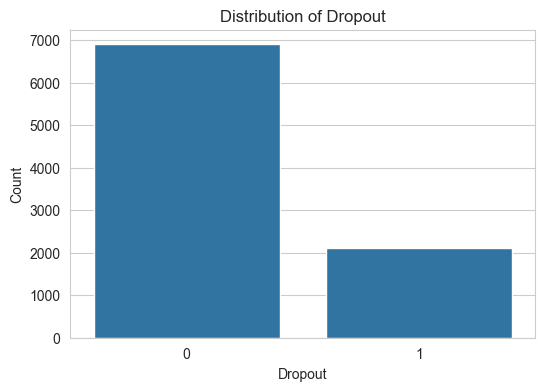

In [16]:
# show the distribution of the target variable (dropout)
plt.figure(figsize=(6, 4))
sns.countplot(x="Dropout", data=df)
plt.title("Distribution of Dropout")
plt.xlabel("Dropout")
plt.ylabel("Count")
plt.show()

The bar chart displays that 0 means that a student has retained and not dropped out, 1 means a student has dropped out. We found this from Kaggle, where it explains the dataset. The barplot shows that around 7,000 students retained and around 2,000 students have dropped out. 

In [17]:
# calculate the percentage of students who dropped out
dropout_percentage = df["Dropout"].mean() * 100
print(f"Percentage of students who dropped out: {dropout_percentage:.2f}%")


Percentage of students who dropped out: 23.48%


The above calculation confirm that 23.48% of students dropped out, this was also shown on Kaggle under the Dataset Characteristics.

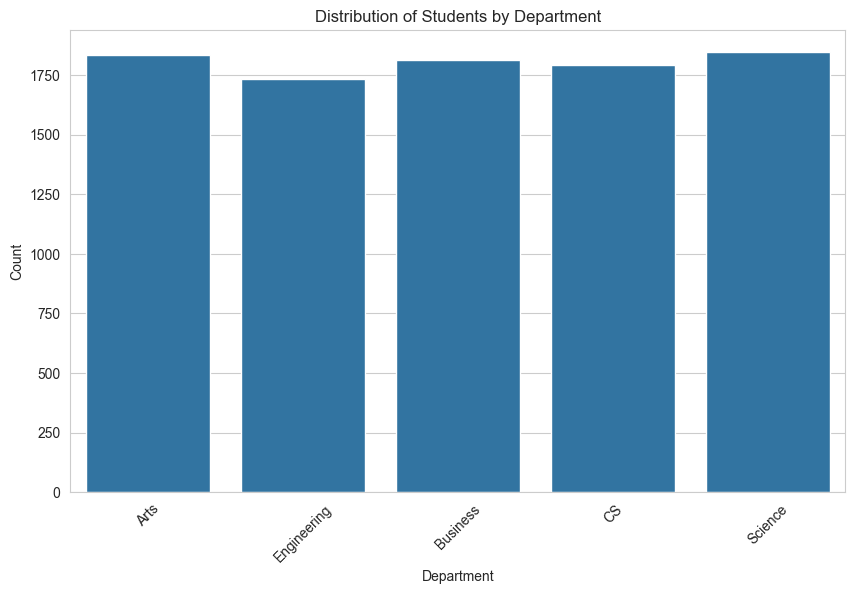

In [61]:
# check how many students are which department using a bar chart
plt.figure(figsize=(10, 6))
sns.countplot(x="Department", data=df)  
plt.title("Distribution of Students by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


The above bar chart shows the amount of students in which department, Arts and Science departments have the most amount of students whereas Engineering has the least amount.

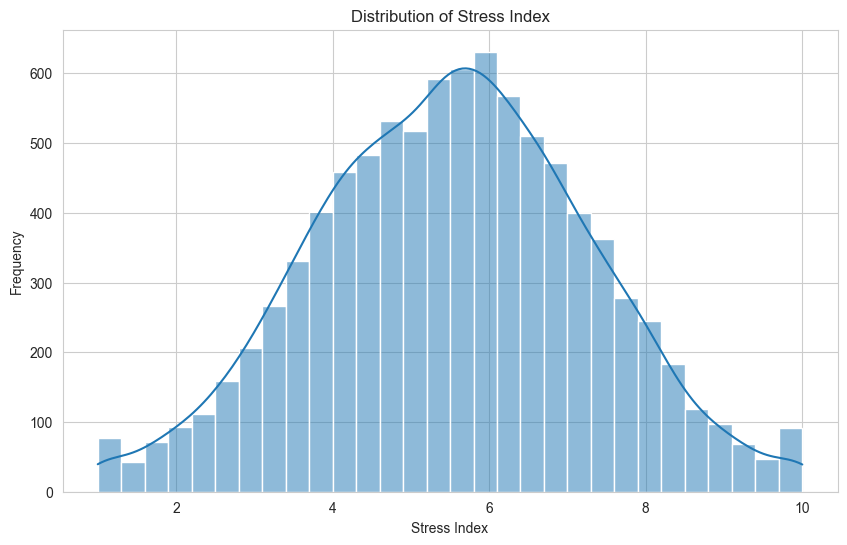

In [56]:
# show the distribution of the variable "Stress_Index"
plt.figure(figsize=(10, 6))
sns.histplot(df["Stress_Index"], bins=30, kde=True)
plt.title("Distribution of Stress Index")
plt.xlabel("Stress Index")
plt.ylabel("Frequency")
plt.show()

The histoplot shows that most students have a stress index between 4-7, there are a small group of students who have the maximum stress index of 10. Stress levels are fairly distributed across students.

## Compare multiple variables

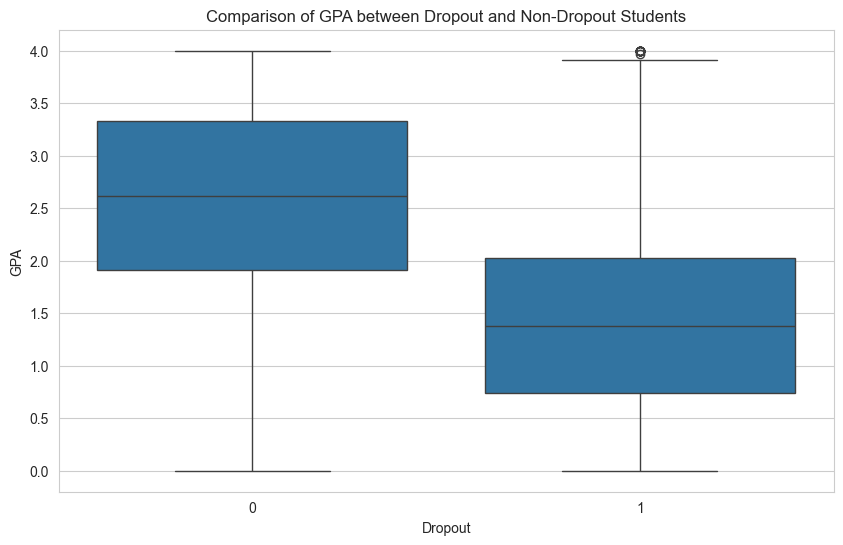

In [20]:
# show comparison of GPA between students who dropped out and those who did not
plt.figure(figsize=(10, 6))
sns.boxplot(x="Dropout", y="GPA", data=df)
plt.title("Comparison of GPA between Dropout and Non-Dropout Students")
plt.xlabel("Dropout")
plt.ylabel("GPA")
plt.show()

The boxplot shows the Dropout vs GPA: The students that have dropped out majorly have lower GPA than students who have retained.

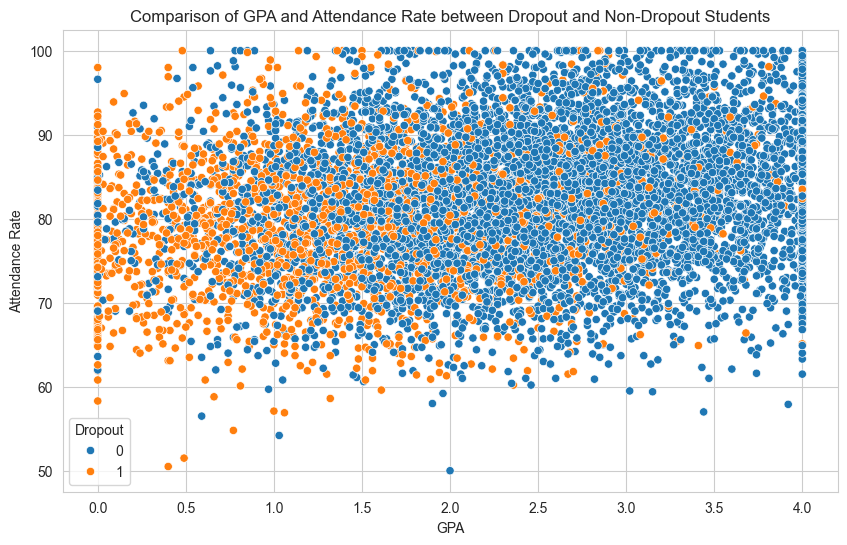

In [22]:
#compare the GPA and the attendance rate of students who dropped out and those who did not
plt.figure(figsize=(10, 6))
sns.scatterplot(x="GPA", y="Attendance_Rate", hue="Dropout", data=df)
plt.title("Comparison of GPA and Attendance Rate between Dropout and Non-Dropout Students")
plt.xlabel("GPA")
plt.ylabel("Attendance Rate")
plt.legend(title="Dropout")
plt.show()

The scatterplot illustrates that the orange dots represent the students who have dropped out and the blue dots show the students who have retained. There are a few orange dots of students that have a high attendance rate but overwhelmingly the plot shows that students who have lower attendance rate have a lower GPA. This links back to BR1 which focuses on Student Performances.

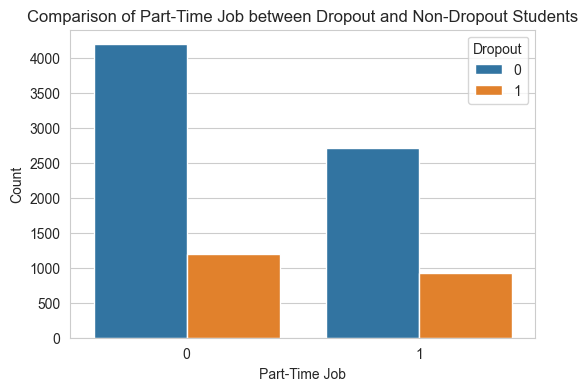

In [24]:
# compare the the amount of students have a part-time job and those who do not have a part-time job and their dropout status
plt.figure(figsize=(6, 4))
sns.countplot(x="Part_Time_Job", hue="Dropout", data=df)
plt.title("Comparison of Part-Time Job between Dropout and Non-Dropout Students")
plt.xlabel("Part-Time Job")
plt.ylabel("Count")
plt.legend(title="Dropout")
plt.show()

The barplot shows the students without a part-time job (4,200) did not drop out vs the 1,200 that did. Students with a part-time job (2,700) did not dropout vs the 950 that did. The dropout rate is very similar so this is not a strong predictor of having a part-time job does not significantly impact students dropping out. The dropout rate is similar between both groups. This links to BR2 which is about wellness.

## Business requirements for comparison

## BR1: Student Performances

* Examine the correlation between attendance rate, daily study hours, scholarship status, and GPA.
* Evaluate whether students receiving scholarships demonstrate higher academic performance.
* Present data relationships using appropriate visualizations such as scatter plots (study hours per day vs. GPA) and heat maps (correlation matrix).


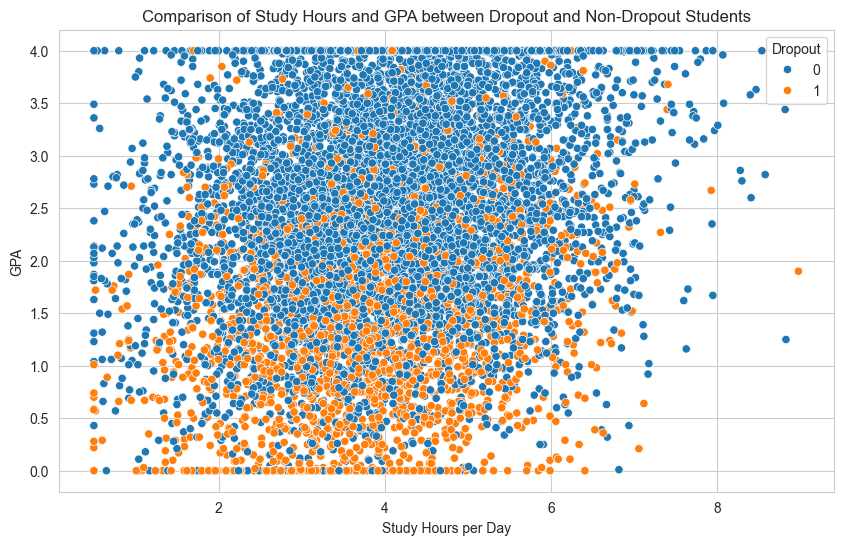

In [27]:
# compare the correlation between studying hours and GPA of students and their dropout status
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Study_Hours_per_Day", y="GPA", hue="Dropout", data=df)
plt.title("Comparison of Study Hours and GPA between Dropout and Non-Dropout Students")
plt.xlabel("Study Hours per Day")
plt.ylabel("GPA")
plt.legend(title="Dropout")
plt.show()

In this scatterplot, the dots are scattered everywhere so there does not seem to be a strong relationship between study hours and GPA. For the dropout vs non-dropout students, they are also spread across everywhere. Although dropout students do tend to cluster slightly at lower GPA hours but this is not a reliable predictor. This satisfies the BR1 requirement to diplay a scatterplot for study hours vs GPA.

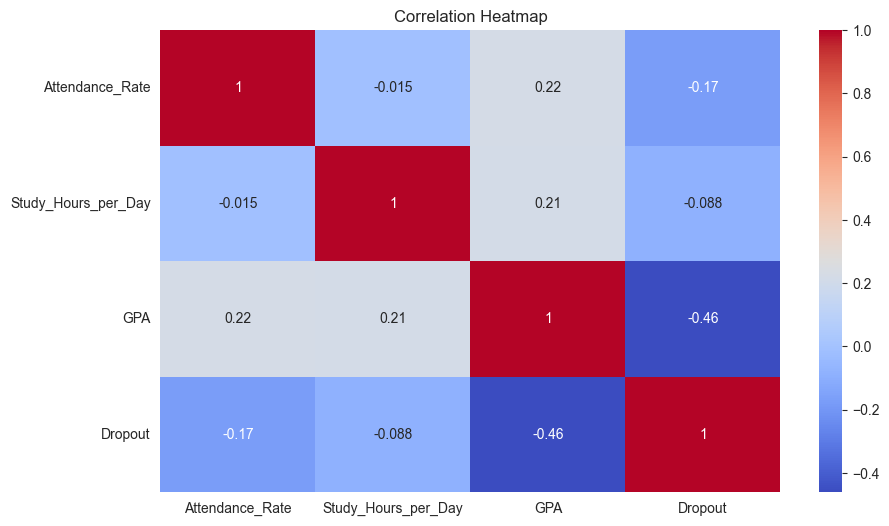

In [28]:
# use a heatmap to show the correlation between attendance rate, study hours, and GPA of students and their dropout status
plt.figure(figsize=(10, 6))
corr = df[["Attendance_Rate", "Study_Hours_per_Day", "GPA", "Dropout"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The heatmap represents the intensity of values using two colours: hot colours represent higher values and cooler colours represent the lower values. 1 means that the variable is perfect as it compares with itself, 0.22 and 0.21 - these are weak positive relationships, this is not a great relationship.
Any numbers that are negative = -0.17, -0.088, -0.015, -0.46 tend to move in opposite directions unless they are close to -1. The closest to -1 is -0.46 so this could be a good relationship. Positive numbers move together and if they are close to 1. The positive numbers are quite far from 1 so these will not be great for comparisons. The Pearson correlation (r) measures the strength between two variables. 
-0.46 is the relationship between GPA vs dropout and this is the strongest relationship.

## BR2: Student’s wellness

* Analyse and compare stress index, travel time minutes, part time job, attendance rate
* Visualisations such as boxplots and bar charts comparing stress index across student groups (those with/without part-time jobs)
* Enable stakeholders (wellness tutors) to access the data to monitor a student’s wellbeing over time


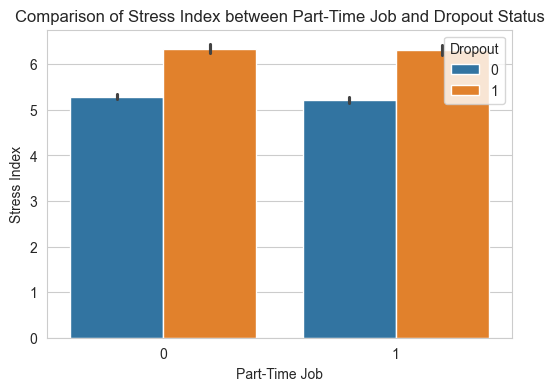

In [37]:
# using a bar chart to compare stress index across student groups those with out a part-time job and those with a part-time job
plt.figure(figsize=(6, 4))
sns.barplot(x="Part_Time_Job", y="Stress_Index", hue="Dropout", data=df)
plt.title("Comparison of Stress Index between Part-Time Job and Dropout Status")
plt.xlabel("Part-Time Job")
plt.ylabel("Stress Index")
plt.legend(title="Dropout")
plt.show()

The Barplot shows the students who have dropped out have a higher stress index regardless whether they have a part time job or not. Stress has a stronger indication of dropout status than students who have a part-time job.

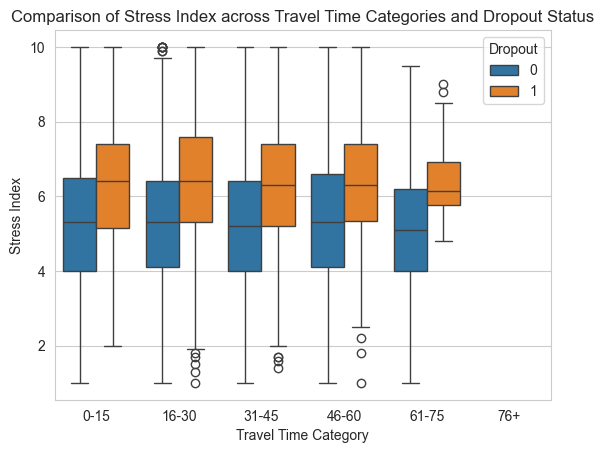

In [43]:
# use pd.cut() that groups travel_time_minutes into categories and compare the stress index across travel time categories and dropout status
df["Travel_Time_Category"] = pd.cut(df["Travel_Time_Minutes"], bins=[0, 15, 30, 45, 60, 75, np.inf], labels=["0-15", "16-30", "31-45", "46-60", "61-75", "76+"])
sns.boxplot(x="Travel_Time_Category", y="Stress_Index", hue="Dropout", data=df)
plt.title("Comparison of Stress Index across Travel Time Categories and Dropout Status")
plt.xlabel("Travel Time Category")  
plt.ylabel("Stress Index")
plt.legend(title="Dropout")
plt.show()

The box plot shows ranges of travel time in minutes (0-15, 16-30, 31-45, 45-60, 61-75 and 76+), highest travel time does not indicate stress levels are highest. The highest stress level is for 16-30 minutes category so it is not a strong indicator that stress relates to students who travel the longest. The dropout status also varies for all the groups, so no clear indicator that there is a strong relationship.

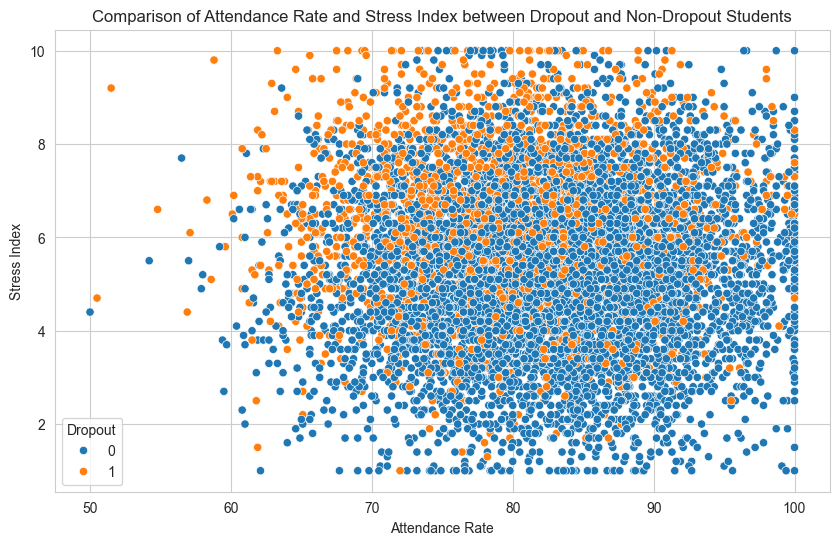

In [45]:
# compare whether students who have a high attendance rate vs stress index are more likely to drop out
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Attendance_Rate", y="Stress_Index", hue="Dropout", data=df)
plt.title("Comparison of Attendance Rate and Stress Index between Dropout and Non-Dropout Students")
plt.xlabel("Attendance Rate")
plt.ylabel("Stress Index")
plt.legend(title="Dropout")
plt.show()

The scatterplot displays that dots are scatterd all over, there is no clear relationship between attendance and stress levels. Very few students have an attendance rate of under 60%, they are mostly clustered around 70-100%. However, students who have lower attendance rate tend to dropout. This is a more reliable indicator than stress alone.

---

## * BR3: Student Biographical Profiling

* Access to biographical and personal data such as age, gender, family income, parental education
* Analyse should highlight demographic clusters that may benefit from targeted interventions.
* Enable stakeholders (government employees) to have access to biographical and socioeconomic data to target outreach programs to specific student demographics.


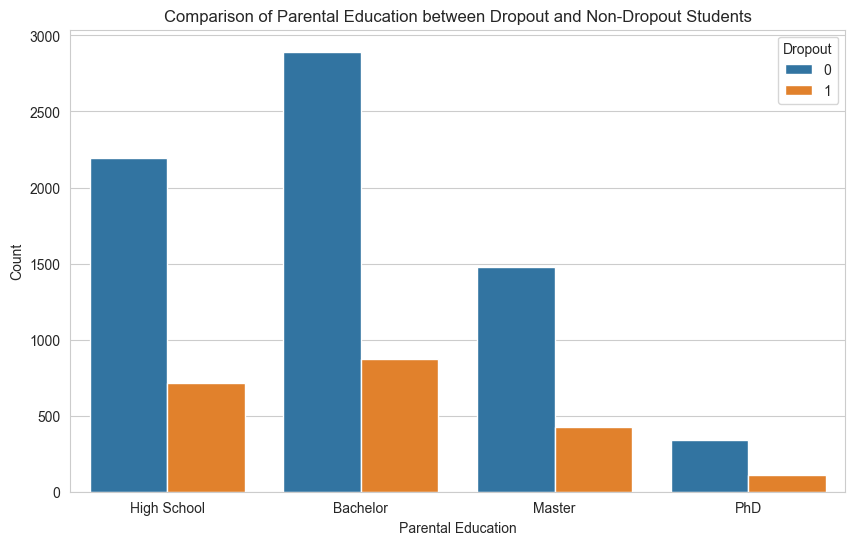

In [50]:
# compare students parental education with droput status
plt.figure(figsize=(10, 6))
sns.countplot(x="Parental_Education", hue="Dropout", data=df)
plt.title("Comparison of Parental Education between Dropout and Non-Dropout Students")
plt.xlabel("Parental Education")
plt.ylabel("Count")
plt.legend(title="Dropout")
plt.show()

The countplot shows the total counts of dropouts are highest in the High School and Bachelor groups, however, the droput rate is relatively consistent between all groups. I will check the percentage for more analysis.

In [51]:
# create a table to show percentage of students who dropped out based on their parental education level
dropout_by_parental_education = df.groupby("Parental_Education")["Dropout"].mean() * 100
dropout_by_parental_education = dropout_by_parental_education.reset_index()
dropout_by_parental_education.columns = ["Parental_Education", "Dropout_Percentage"]
print(dropout_by_parental_education)


  Parental_Education  Dropout_Percentage
0           Bachelor           23.119851
1        High School           24.543890
2             Master           22.344900
3                PhD           24.444444


The above table confirms there is not much difference between dropout and parental education, so this is not a good relationship.

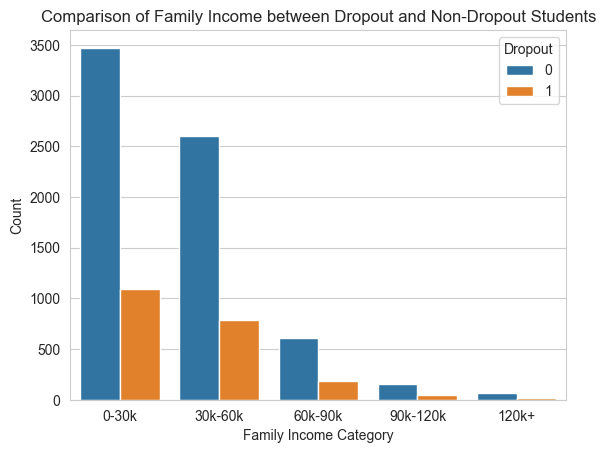

In [54]:
# compare the family income of students who dropped out and those who did not drop out using a bar chart
# bin the family income into categories
df["Family_Income_Category"] = pd.cut(df["Family_Income"], bins=[0, 30000, 60000, 90000, 120000, np.inf], labels=["0-30k", "30k-60k", "60k-90k", "90k-120k", "120k+"])
sns.countplot(x="Family_Income_Category", hue="Dropout", data=df)
plt.title("Comparison of Family Income between Dropout and Non-Dropout Students")
plt.xlabel("Family Income Category")
plt.ylabel("Count")
plt.legend(title="Dropout")
plt.show()


The countplot shows the total counts of dropouts are highest in Family Income of 0-30K and 30K-60K, however, the dropout rate is relatively consistent between all groups. I will check the percentage for more analysis.

In [ ]:
# create a table to show the percentage of students who dropped out based on their family income category
dropout_by_family_income = df.groupby("Family_Income_Category")["Dropout"].mean() * 100
dropout_by_family_income = dropout_by_family_income.reset_index()
dropout_by_family_income.columns = ["Family_Income_Category", "Dropout_Percentage"]
print(dropout_by_family_income)

  Family_Income_Category  Dropout_Percentage
0                  0-30k           23.909709
1                30k-60k           23.158829
2                60k-90k           23.522013
3               90k-120k           20.792079
4                  120k+           18.987342


C:\Users\leha_\AppData\Local\Temp\ipykernel_42188\1661562661.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dropout_by_family_income = df.groupby("Family_Income_Category")["Dropout"].mean() * 100


The above table displays students who have a family Income of 120K+ have an 18.9% chance of dropping out compared to students whose family income is 0-30K have a slightly higher percentage of 23.9% of dropping out. This differences are realtively small.

## Conclusion

* The initial data exploration shows that this dataset has 9,020 students and 19 columns, it also confirms the data is clean. 
* The droput percentage of students is 23.48%. 
* Students who have a lower GPA are more likely to dropout, with a correlation of -0.46
* Dropout students show higher stress levels regardless if they have a part-time job or not
* Students who have lower attendance rates tend to dropout
* Parental education and family income show only minimal differences between students that dropout to those that retain.



## Reflections

* The travel time graph was the most challenging visualisation due to the continuous nature of the variable — binning resolved this
* Adding dropout as a hue across all graphs added more depth than originally planned
* Some variables such as study hours showed weaker relationships than expected
* These findings directly feed into BR1, BR2, and BR3.





NOTE

* You may add as many sections as you want, as long as it supports your project workflow.
* All notebook's cells should be run top-down (you can't create a dynamic wherein a given point you need to go back to a previous cell to execute some task, like go back to a previous cell and refresh a variable content)

---